# **EDA for Uplift Modelling of a Marketing Campaign.**

## **Load Data.**

In [1]:
import os
import pandas as pd

DATASETS_PATH = os.getenv("DATASETS_PATH")
DATASETS_PATH = DATASETS_PATH + "/MarketingUpliftModelling/"

data_df = pd.read_csv(DATASETS_PATH + "Kevin_Hillstrom_MineThatData_E-MailAnalytics.csv")

print("Data: ")
print(data_df)


Data: 
       recency history_segment  history  mens  womens   zip_code  newbie  \
0           10  2) $100 - $200   142.44     1       0  Surburban       0   
1            6  3) $200 - $350   329.08     1       1      Rural       1   
2            7  2) $100 - $200   180.65     0       1  Surburban       1   
3            9  5) $500 - $750   675.83     1       0      Rural       1   
4            2    1) $0 - $100    45.34     1       0      Urban       0   
...        ...             ...      ...   ...     ...        ...     ...   
63995       10  2) $100 - $200   105.54     1       0      Urban       0   
63996        5    1) $0 - $100    38.91     0       1      Urban       1   
63997        6    1) $0 - $100    29.99     1       0      Urban       1   
63998        1  5) $500 - $750   552.94     1       0  Surburban       1   
63999        1  4) $350 - $500   472.82     0       1  Surburban       0   

            channel        segment  visit  conversion  spend  
0             Pho

## **Describe Column names and values**

The column named **'recency'** represents number of month since last purchase. Let's see how the values are distributed.

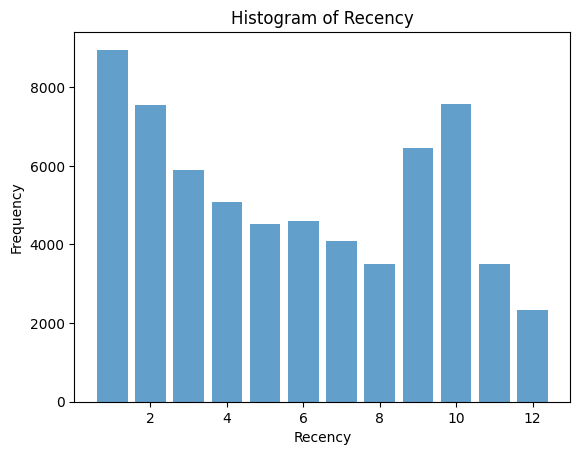

In [2]:
import matplotlib.pyplot as plt

# plot histogram of recency
counts = data_df["recency"].value_counts().sort_index()

# plot
plt.bar(counts.index, counts.values, alpha = 0.7)

plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.title("Histogram of Recency")

plt.show()

The distribution is inhomogenous. There strong peaks for recent customers around 0 and for inactive, that made the last purchase around 8 to 10 months ago. There is also a small peak for average values around 6 months. Generally, it would make no sence to treat recently purchasers with E-mails, because they would buy anyway. It is also not very sensefull to treat inactive customers. But for the correct uplift modelling treatment should be randomized for customers with all recencies.   

Let's see how the treatment is distributed for **'recency'** values

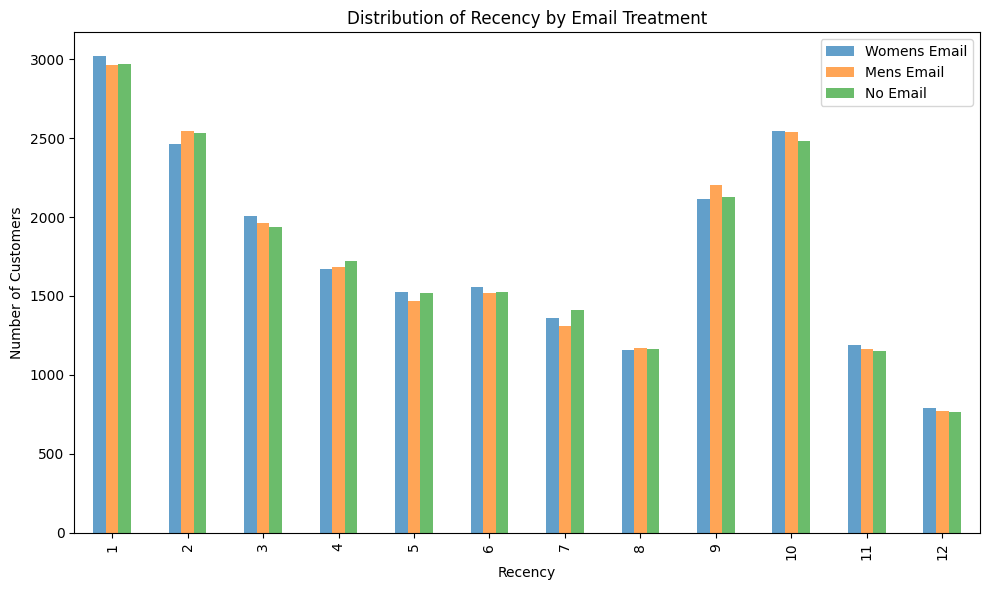

In [3]:
# split by treatment
women = data_df[data_df["segment"] == "Womens E-Mail"]
men = data_df[data_df["segment"] == "Mens E-Mail"]
control = data_df[data_df["segment"] == "No E-Mail"]

# count recency per group
women_counts = women["recency"].value_counts().sort_index()
men_counts = men["recency"].value_counts().sort_index()
control_counts = control["recency"].value_counts().sort_index()

# combine into one dataframe
plot_df = pd.DataFrame({
    "Womens Email": women_counts,
    "Mens Email": men_counts,
    "No Email": control_counts
}).fillna(0)

# grouped bar plot
plot_df.plot(kind="bar", figsize=(10,6), alpha = 0.7)

plt.xlabel("Recency")
plt.ylabel("Number of Customers")
plt.title("Distribution of Recency by Email Treatment")
plt.legend()
plt.tight_layout()
plt.show()

The treatment distribution looks very similar for each recency group. It means that for each treatment group, there is approximately the same number of participants.

The column **'history_segment'** represents the range of purchase amount for each customer and the column **'history'** - the exact amount of purchases. We now consider how the treatment is distributed for these groups in the column 'history_segment'

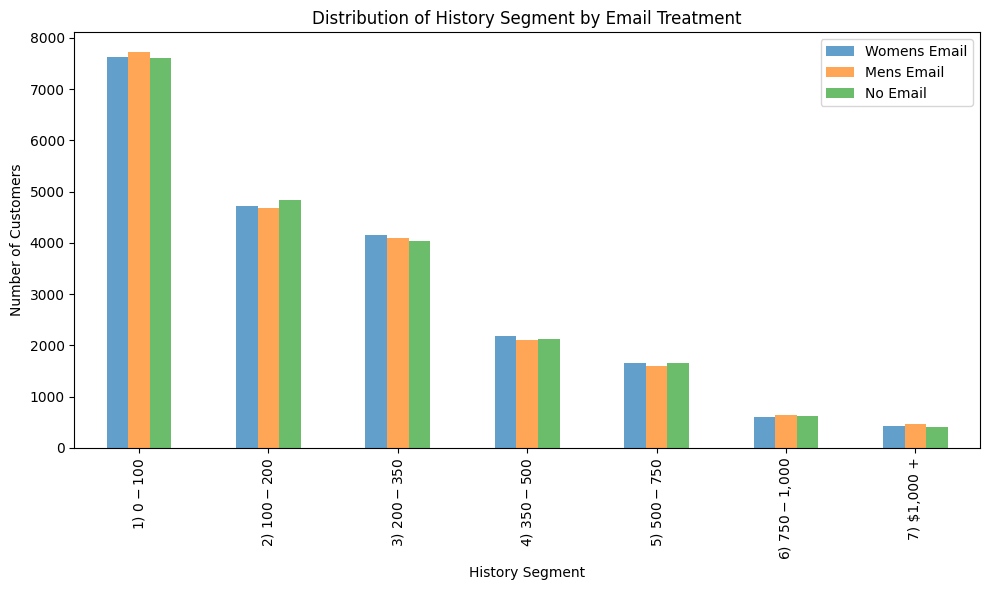

In [4]:
# split by treatment
women = data_df[data_df["segment"] == "Womens E-Mail"]
men = data_df[data_df["segment"] == "Mens E-Mail"]
control = data_df[data_df["segment"] == "No E-Mail"]

# count history segments per group
women_counts = women["history_segment"].value_counts().sort_index()
men_counts = men["history_segment"].value_counts().sort_index()
control_counts = control["history_segment"].value_counts().sort_index()

# combine into dataframe
plot_df = pd.DataFrame({
    "Womens Email": women_counts,
    "Mens Email": men_counts,
    "No Email": control_counts
}).fillna(0)

# plot grouped bar chart
plot_df.plot(kind="bar", figsize=(10,6), alpha = 0.7)

plt.xlabel("History Segment")
plt.ylabel("Number of Customers")
plt.title("Distribution of History Segment by Email Treatment")
plt.legend()
plt.tight_layout()
plt.show()

Again, the treatment is very homogeniously distributed for each history segement (which could be not the case for a custom dataset), though the resulting amount of customers is far less for higher purchases amounts.

The columns **'mens'** and **'womens'** build 4 categories of buyers:
* **general buyers (0,0):** the customers could not be categorised eather mens or womens products buyers. It could happen due to lack of information, or statistical evidence for categorization.
* **mens buyers (1,0):** they buy generally mens products.
* **womens buyers (0,1):** they buy generally womens products.
* **both mens and womens buyers (1,1):** they buy statistically equal emounts of mens and womens products.


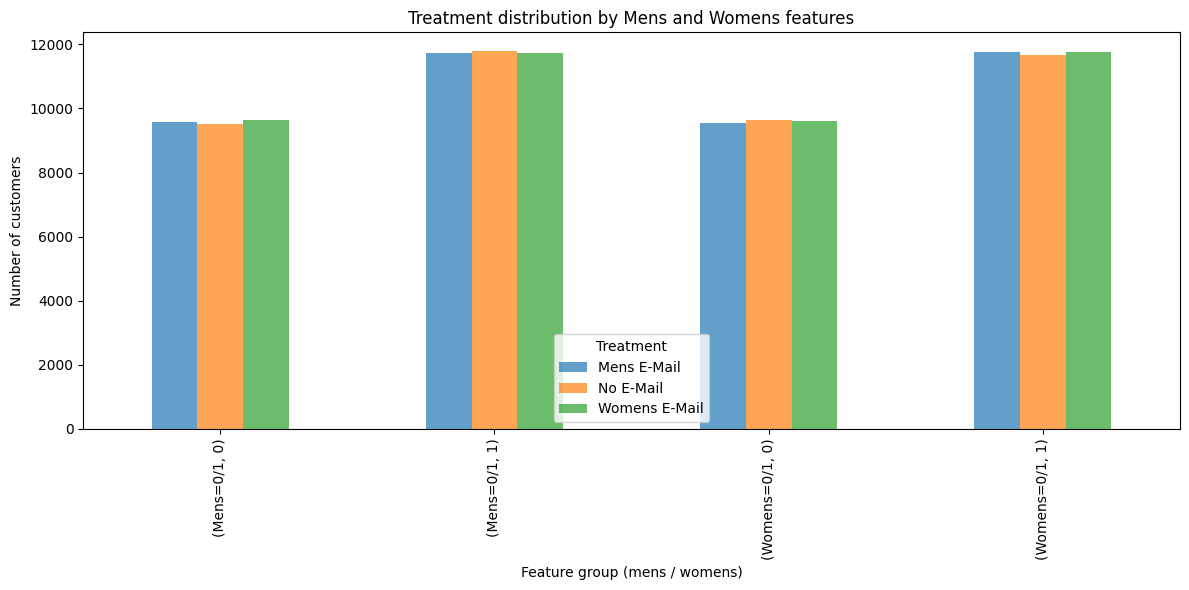

In [5]:
# mens feature vs treatment
mens_table = pd.crosstab(data_df["mens"], data_df["segment"])

# womens feature vs treatment
womens_table = pd.crosstab(data_df["womens"], data_df["segment"])

plot_df = pd.concat(
    {
        "Mens=0/1": mens_table,
        "Womens=0/1": womens_table
    },
    axis=0
).fillna(0)

plot_df.plot(kind="bar", figsize=(12,6), alpha = 0.7)

plt.xlabel("Feature group (mens / womens)")
plt.ylabel("Number of customers")
plt.title("Treatment distribution by Mens and Womens features")
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

There are small differencies in customer numbers for each group, but the distribution of treatment groups is comparable.

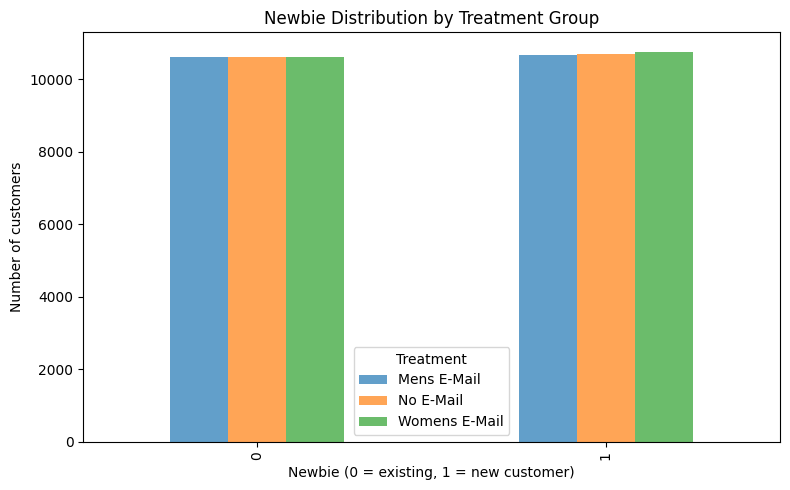

In [6]:
# count newbie (0/1) within each treatment group
table = pd.crosstab(data_df["newbie"], data_df["segment"])

# plot grouped bars
table.plot(kind="bar", figsize=(8,5), alpha = 0.7)

plt.xlabel("Newbie (0 = existing, 1 = new customer)")
plt.ylabel("Number of customers")
plt.title("Newbie Distribution by Treatment Group")
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

There is no disbalance in treatment and group participants numbers for this column.

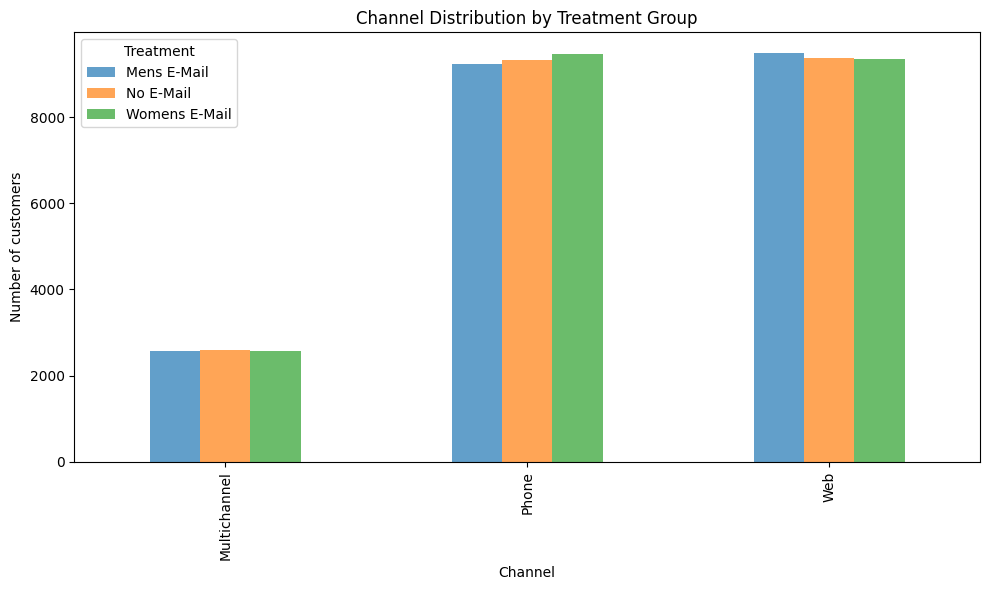

In [8]:
# count channel within each treatment group
table = pd.crosstab(data_df["channel"], data_df["segment"])

# plot grouped bars
table.plot(kind="bar", figsize=(10,6), alpha = 0.7)

plt.xlabel("Channel")
plt.ylabel("Number of customers")
plt.title("Channel Distribution by Treatment Group")
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

One can see that the channels 'Phone' and 'Web' are more populated then 'Multichannel', but the most important thing is, that the treatment is homogeniously distributed for all channels, so that there is no disbalance for any treament group.

Lets check the distribution of treatment for column **'zip_code'**.

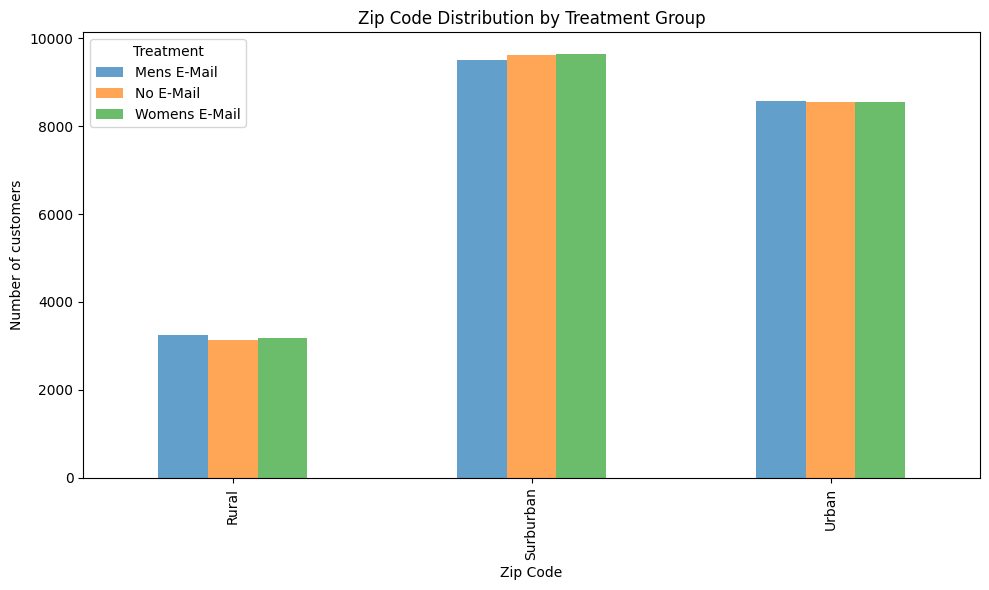

In [12]:
# count zip code within each treatment group
table = pd.crosstab(data_df["zip_code"], data_df["segment"])

# plot grouped bars
table.plot(kind="bar", figsize=(10,6), alpha = 0.7)

plt.xlabel("Zip Code")
plt.ylabel("Number of customers")
plt.title("Zip Code Distribution by Treatment Group")
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

No disbalance in treatments distribution for this category as well.

Now we calculate the **rates of visit and conversion** for each treatment group.

In [9]:
# group by treatment (segment) and compute mean rates
rates = data_df.groupby("segment")[["visit", "conversion"]].mean()

print(rates)

                  visit  conversion
segment                            
Mens E-Mail    0.182757    0.012531
No E-Mail      0.106167    0.005726
Womens E-Mail  0.151400    0.008837


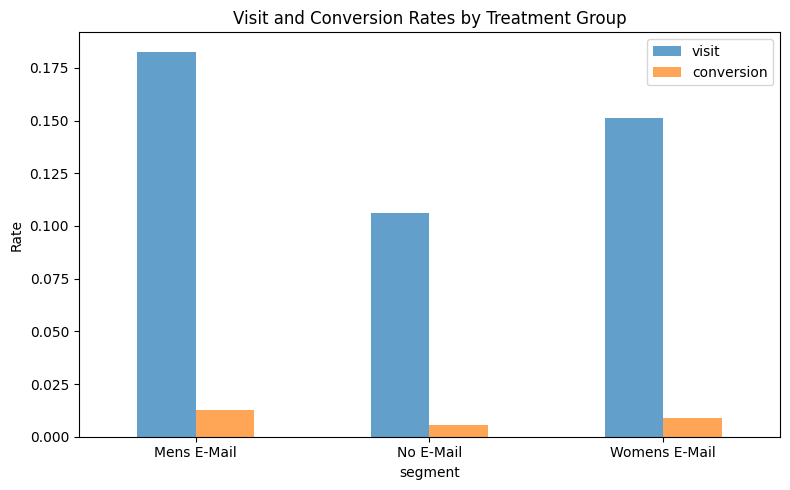

In [11]:
rates.plot(kind="bar", figsize=(8,5), alpha = 0.7)

plt.ylabel("Rate")
plt.title("Visit and Conversion Rates by Treatment Group")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

The segment 'No E-mail' gives us a baseline for visit and conversion rates. It is obvious, that there is an effect of treatment for both segments 'Mens E-mail' and 'Womens E-mail'. The visit rates are around 10 times bigger that conversion rates in average for all treatment groups.

## **Conclusions of the EDA:**
* The dataset is perfectly balanced according to treatments groups distribution in all categorical and numeric columns in the dataset, which makes it a good material for the uplift modelling of a marketing campaign.
* There is an obvious increase in conversions and visits comparing to a baseline in the control group. 